In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the Database in Python

In [1]:
import os
os.getcwd()

'c:\\Users\\kolad\\OneDrive\\Documents\\Data Science Project\\Chinook_SQL'

In [2]:
os.listdir()

['.venv', 'chinook.ipynb', 'Chinook_Sqlite (1).sqlite']

In [5]:
import sqlite3
conn = sqlite3.connect("Chinook_Sqlite.sqlite")

print("Connected successfully!")



Connected successfully!


#### Explore the Database Schema

In [8]:
query = "SELECT name FROM sqlite_master WHERE type='table';"

tables = pd.read_sql(query, conn)

tables

,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


 ### Understanding Relationship
 
 Preview the columns in some of the tables to understand the relationship that exist between the tables in the relational database

In [23]:
pd.read_sql("SELECT * FROM track LIMIT 3;", conn)

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99


In [24]:
pd.read_sql("SELECT * FROM InvoiceLine LIMIT 3;", conn)

,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity
0,1,1,2,0.99,1
1,2,1,4,0.99,1
2,3,2,6,0.99,1


In [25]:
pd.read_sql("SELECT * FROM Invoice LIMIT 3;", conn)

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2021-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2021-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,3,8,2021-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94


In [26]:
pd.read_sql("SELECT * FROM Customer LIMIT 3;", conn)

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3


In [41]:
pd.read_sql("SELECT * FROM Employee LIMIT 3;", conn)

,EmployeeId,LastName,FirstName,Title,ReportsTo,BirthDate,HireDate,Address,City,State,Country,PostalCode,Phone,Fax,Email
0,1,Adams,Andrew,General Manager,NaN,1962-02-18 00:00:00,2002-08-14 00:00:00,11120 Jasper Ave NW,Edmonton,AB,Canada,T5K 2N1,+1 (780) 428-9482,+1 (780) 428-3457,andrew@chinookcorp.com
1,2,Edwards,Nancy,Sales Manager,1.0,1958-12-08 00:00:00,2002-05-01 00:00:00,825 8 Ave SW,Calgary,AB,Canada,T2P 2T3,+1 (403) 262-3443,+1 (403) 262-3322,nancy@chinookcorp.com
2,3,Peacock,Jane,Sales Support Agent,2.0,1973-08-29 00:00:00,2002-04-01 00:00:00,1111 6 Ave SW,Calgary,AB,Canada,T2P 5M5,+1 (403) 262-3443,+1 (403) 262-6712,jane@chinookcorp.com


From the above, Customer is linked to Invoice table

The invoice table is linked to the InvoiceLine

The invoice Line is then linked to the Track table

This is how sales flow:
Customer buys → Invoice → InvoiceLine → Track

### Business Question

#### Top 10 Best- Selling Tracks

In [29]:
query = """

SELECT t.Name AS Track_Name,
SUM(il.Quantity) AS Total_Sold
FROM InvoiceLine il
JOIN Track t ON il.TrackId = t.TrackId
GROUP BY t.TrackId
ORDER BY Total_Sold DESC
LIMIT 10;   

"""

top_tracks = pd.read_sql(query, conn)
top_tracks

,Track_Name,Total_Sold
0,Balls to the Wall,2
1,Inject The Venom,2
2,Snowballed,2
3,Overdose,2
4,Deuces Are Wild,2
5,Not The Doctor,2
6,Por Causa De Você,2
7,Welcome Home (Sanitarium),2
8,Snowblind,2
9,Cornucopia,2


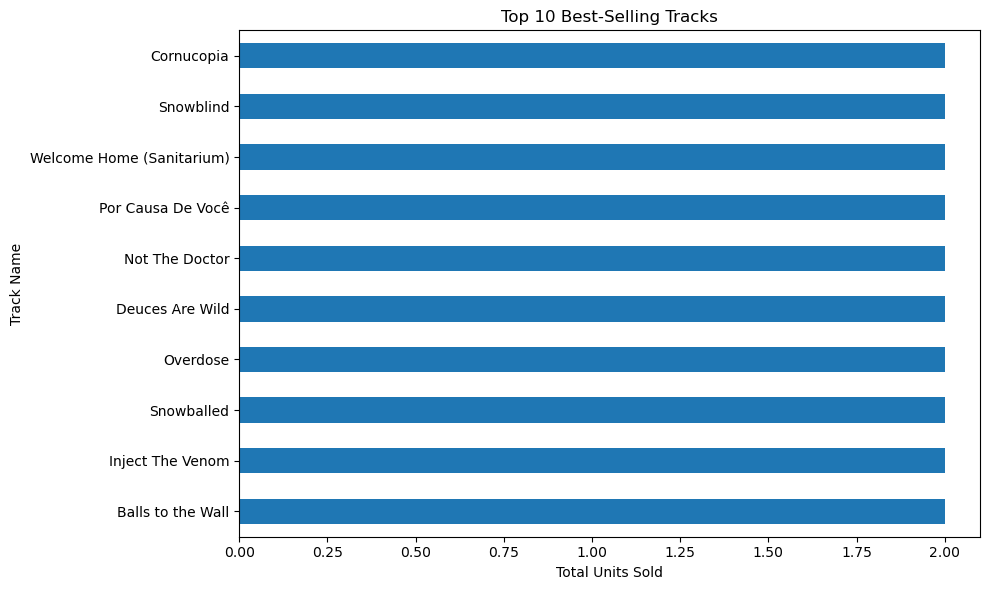

In [36]:
# Visualize the top-selling tracks

top_tracks.plot(
    kind='barh',
    x='Track_Name',
    y='Total_Sold',
    figsize=(10, 6),
    legend=False,
    
)

plt.title('Top 10 Best-Selling Tracks')
plt.xlabel('Total Units Sold')  
plt.ylabel('Track Name')
plt.tight_layout()
plt.show() 

#### Which country generates the most revenue?

In [40]:
query = """

SELECT
Billingcountry AS Country,
SUM(Total) AS Total_Sales
FROM Invoice i
GROUP BY Billingcountry
ORDER BY Total_Sales DESC;   

"""

sales_by_country = pd.read_sql(query, conn)
sales_by_country.head()

,Country,Total_Sales
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48


#### Who is the top-performing sales employee?

In [48]:
query = """
SELECT 
    e.FirstName || ' ' ||  e.LastName AS Employee,
    SUM(i.Total) AS Total_Sales
FROM Employee e
JOIN Customer c ON e.EmployeeId = c.SupportRepId
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY e.EmployeeId
ORDER BY Total_Sales DESC;
"""

top_employee = pd.read_sql(query, conn)
top_employee

,Employee,Total_Sales
0,Jane Peacock,833.04
1,Margaret Park,775.40
2,Steve Johnson,720.16


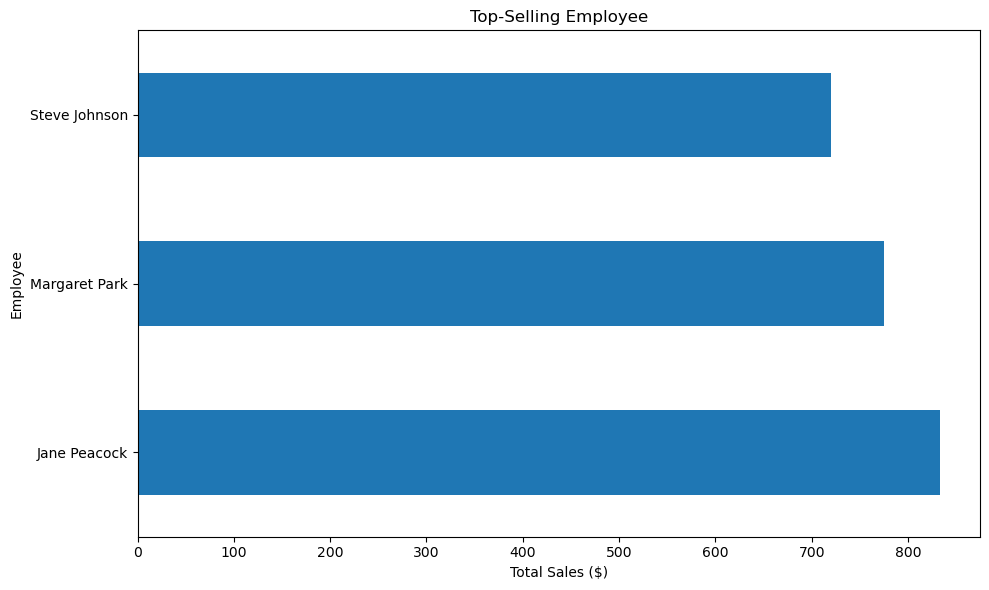

In [53]:
# Visualize the top-selling employee
top_employee.plot(
    kind='barh',
    x='Employee',
    y='Total_Sales',
    figsize=(10, 6),
    legend=False,
    
)
plt.title('Top-Selling Employee')
plt.xlabel('Total Sales ($)')  
plt.ylabel('Employee')  
plt.tight_layout()
plt.show()         